# Optimización Bayesiana

Julieta Madrigal Flores - 744029

Jueves 19 de marzo del 2026

**Teorema de Bayes**

$$ P(A|B) = \frac{P(B|A) P(A)}{P(B)} $$

$ P(A|B) $: Probabilidad condicional de A dado B. También conocida como la probabilidad posterior de A dado que B ocurre.

$ P(B|A) $: Probabilidad condicional de B dado A. Se interpreta como la verosimilitud (*likelihood*) de A.

$ P(A) $: Probabilidad de observar A. También conocida como probabilidad a priori.

$ P(B) $: Probabilidad de observar B. Interpretada como evidencia.

Utilizando las definiciones de arriba actualizamos la definición del teorema de bayes:

$$ \text{posterior} = \frac{(\text{verosimilitud})(\text{anterior})}{\text{evidencia}} $$

La intuición es que el teorema de Bayes es una herramienta para actualizar nuestras creencias dado lo que se tenía antes y nueva evidencia. Por ejemplo, tomas una moneda y asumes que es una moneda justa, dado que es lo más probable y que las monedas suelen ser justas en tu experiencia. Lanzas la moneda tres veces y cae sello las tres veces; un poco extraño, así que ajustas tus creencias y empiezas a imaginar que la moneda no es tan justa como debería ser. Lanzas las monedas tres veces y cae águila; ahora crees que la moneda es justa de nuevo.

## ¿Cómo aplicamos esto en nuestra vida diaria?

Imagina que tienes 3 puntos (conocimiento previo) en un espacio.

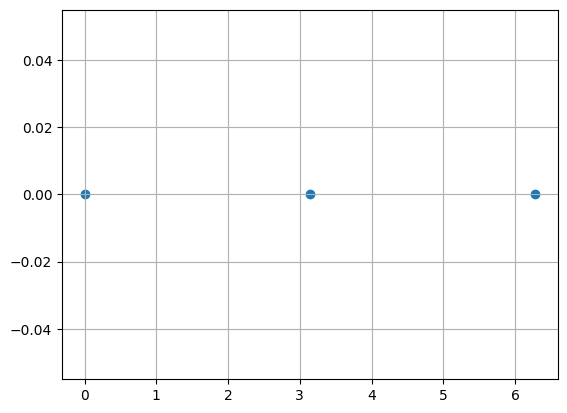

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(); plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0]); plt.grid()

No hay seguridad de cómo se conectan estos puntos, pero sabes que están conectados. Hay infinitas formas en las que estos puntos se pueden conectar.

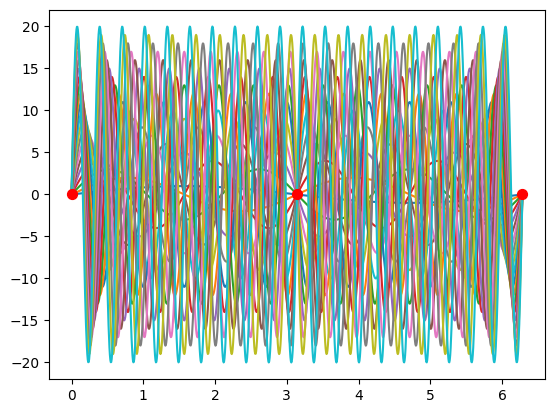

In [ ]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure();
for i in range(20) :
    y = (i+1)*np.sin((i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0], s=50, c="r", zorder=3)

Hay tanta incertidumbre que decides pedir más información y te dan otro punto.

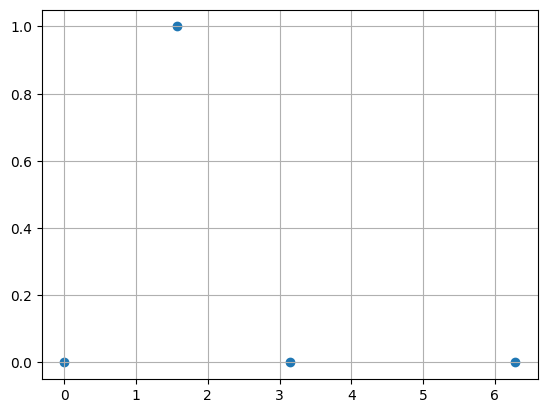

In [ ]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1]); plt.grid()

Con esta nueva información actualizas tus creencias y reduces la cantidad de formas en las que se conectan estos puntos (siguen siendo infinitas).

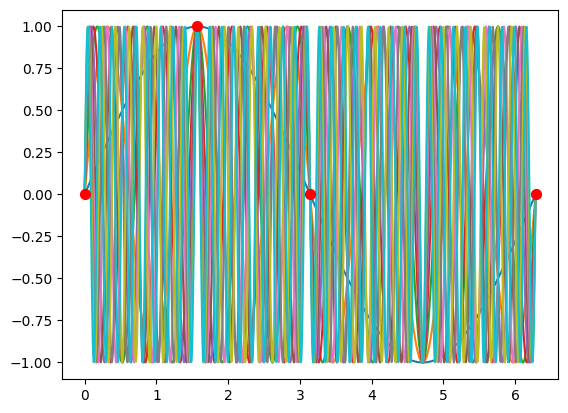

In [ ]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure();
for i in range(10) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Te pones a pensar: "Sí. Teóricamente hay infinitas funciones que pueden conectar estos puntos, pero sólo algunas tienen sentido dado mi contexto."

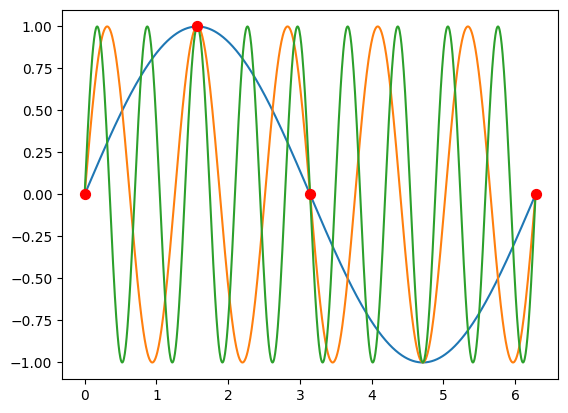

In [ ]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure();
for i in range(3) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Ahora sólo quedan algunos pocos candidatos dado el criterio que tienes. Hay incertidumbre sobre cuál de estos candidatos podría ser el que mejor se ajusta, así que decides pedir más información. ¿Qué información serviría más?
- Se podría pedir el valor de $y$ cuando $x=\frac{3\pi}{2}$, pero los candidatos que tenemos todos pasan por el mismo punto. Incluso si nos dieran la información, no ayudaría de mucho.
- Se podría pedir fuera del rango que tenemos, pero quizás la información no existe o dado el contexto del problema es imposible que estos puntos existan.

Nos asignan nuestro último punto.

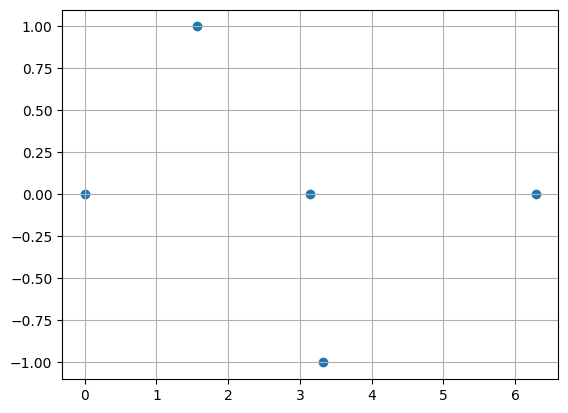

In [ ]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1]); plt.grid()

Usamos esta nueva información (evidencia) junto con lo que conocíamos (anterior) y lo que creemos que es posible (verosimilitud) para decidir sobre una nueva función (posterior).

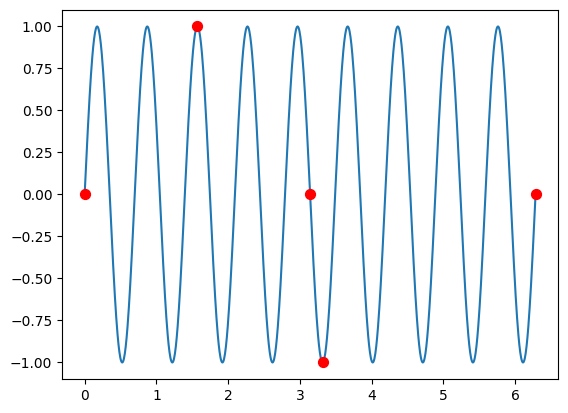

In [ ]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); y = np.sin(9*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1], s=50, c="r", zorder=3)

Una forma de realizar este experimento es mediante un proceso gaussiano, que asume que la variable de salida es una variable aleatoria con distribución normal multivariada. Utilicemos la función que encontramos y asumamos que no sabemos cuál es.

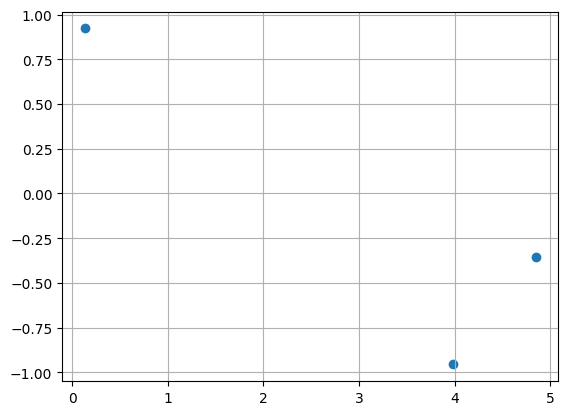

In [3]:
np.random.seed(10)
def f(x) :
    return np.sin(9*x)
X = np.random.uniform(0, 2*np.pi, 3).reshape([-1, 1])
plt.figure(); plt.scatter(X, f(X)); plt.grid()

Realizamos una regresión de proceso gaussiano para encontrar distribuciones que podrían darnos estas muestras

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.pipeline import Pipeline

# definimos la función
np.random.seed(10)
def f(x):
    return np.sin(9*x)


In [5]:
# Generamos los datos de entrenamiento
X_train = np.random.uniform(0, 2*np.pi, 3).reshape([-1, 1])
y_train = f(X_train)

# Creamos y entrenamos el PIPELINE con regresión de proceso Gaussiano
modelo_gauss = Pipeline([
    ('gp', GaussianProcessRegressor(random_state=42))])

modelo_gauss.fit(X_train, y_train)

Pipeline(steps=[('gp', GaussianProcessRegressor(random_state=42))])

Creamos un vector de valores posibles de $x$ y predecimos $y$ usando el resultado de la regresión.

In [6]:
# Creamos un vector de valores posibles de X y predecimos Y
X_test = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_pred_mean, y_pred_std = modelo_gauss.predict(X_test, return_std=True)


Graficamos nuestra primera propuesta, utilizando el error estándar para dibujar nuestros intervalos de confianza.

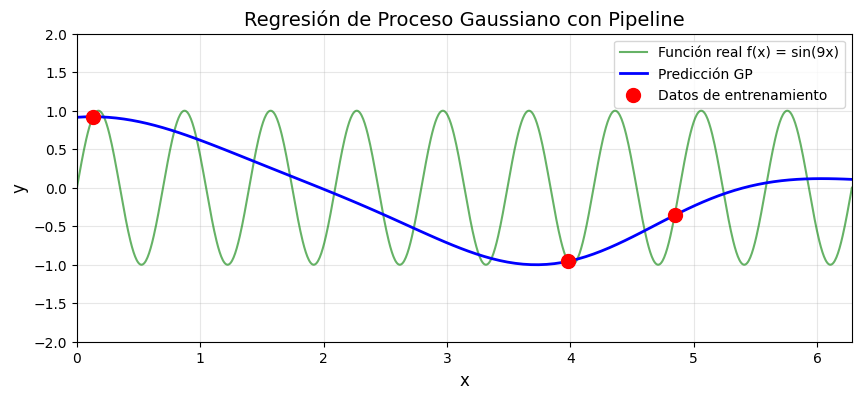

In [7]:
plt.figure(figsize=(10, 4))

# Graficamos la función real para referencia
X_real = np.linspace(0, 2*np.pi, 1000)
y_real = f(X_real)
plt.plot(X_real, y_real, 'g-', label='Función real f(x) = sin(9x)', alpha=0.6)

# Graficamos la media de la predicción
plt.plot(X_test, y_pred_mean, 'b-', label='Predicción GP', linewidth=2)

# Graficamos los puntos de entrenamiento
plt.scatter(X_train, y_train, color='red', s=100, zorder=5, label='Datos de entrenamiento')

# Configuramos el gráfico
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Regresión de Proceso Gaussiano con Pipeline', fontsize=14)
plt.legend(fontsize=10)
plt.xlim(0, 2*np.pi)
plt.ylim(-2, 2)
plt.show()

Podemos ver que necesitamos más muestras debido a que hay mucha incertidumbre en algunas partes de nuestro dominio. Hay varios criterios para decidir cómo pedir muestras:
- Maximizar (busco mi predicción del máximo actual y pido esa medida)

In [8]:
idx_max = np.argmax(y_pred_mean)
x_max = X_test[idx_max][0]

- Minimizar (busco mi predicción del mínimo actual y pido esa medida)

In [9]:
idx_min = np.argmin(y_pred_mean)
x_min = X_test[idx_min][0]

- Reducir incertidumbre (busco el punto donde mi intervalo de confianza es más grande y pido esa medida)

In [22]:
# El intervalo de confianza (95%) es media ± 2*std, su ancho es 4*std
ancho_intervalo = 4 * y_pred_std

# Punto con intervalo más grande
idx_uncertainty = np.argmax(ancho_intervalo)
x_uncertainty = X_test[idx_uncertainty][0]

Y repetimos el proceso ya con nueva información.

In [12]:
# Función para entrenar y predecir con nuevos datos
def entrenar_y_predecir(X_train_new, y_train_new):
    pipeline = Pipeline([('gp', GaussianProcessRegressor(random_state=42))])
    pipeline.fit(X_train_new, y_train_new)
    return pipeline.predict(X_test, return_std=True)

- Maximizar

In [20]:
X_train_max = np.vstack([X_train, [[x_max]]])
y_train_max = np.append(y_train, f(x_max))

# AQUI es donde utilizamos la función que definimos arriba
y_pred_max, y_std_max = entrenar_y_predecir(X_train_max, y_train_max)


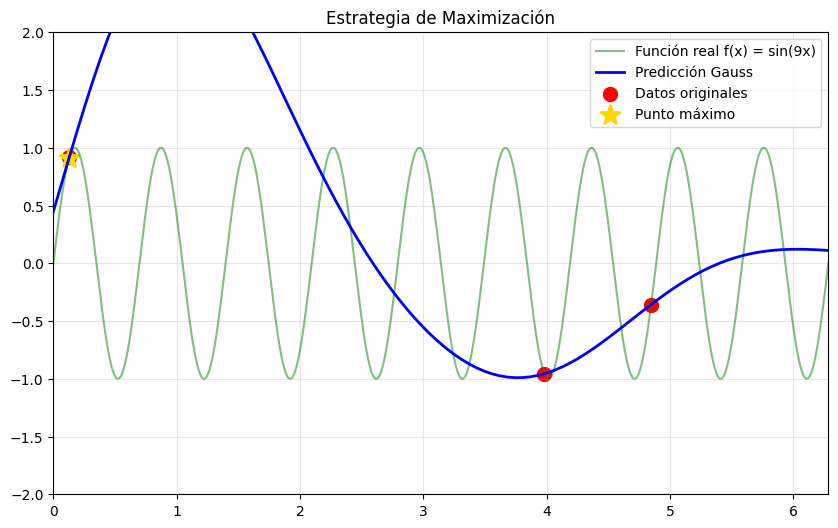

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(X_real, y_real, 'g-', alpha=0.5, label='Función real f(x) = sin(9x)')
plt.plot(X_test, y_pred_max, 'b-', label='Predicción Gauss', linewidth=2)
plt.scatter(X_train, y_train, color='red', s=100, label='Datos originales')
plt.scatter([x_max], f(x_max), color='gold', s=200, marker='*', linewidth=2, label=f'Punto máximo')

plt.title(f'Estrategia de Maximización')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 2*np.pi)
plt.ylim(-2, 2)
plt.show()

- Minimizar

In [18]:
X_train_min = np.vstack([X_train, [[x_min]]])
y_train_min = np.append(y_train, f(x_min))

# AQUI es donde utilizamos la función que definimos arriba
y_pred_min, y_std_min = entrenar_y_predecir(X_train_min, y_train_min)


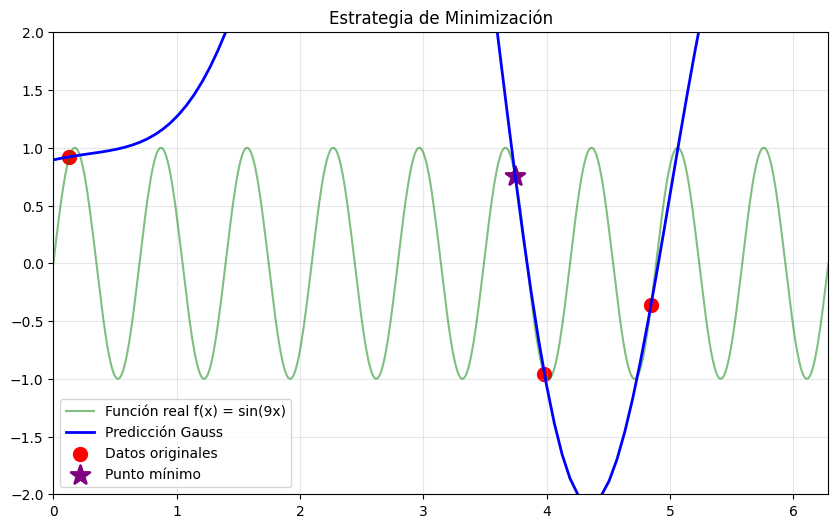

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(X_real, y_real, 'g-', alpha=0.5, label='Función real f(x) = sin(9x)')
plt.plot(X_test, y_pred_min, 'b-', label='Predicción Gauss', linewidth=2)
plt.scatter(X_train, y_train, color='red', s=100, label='Datos originales')
plt.scatter([x_min], f(x_min), color='purple', s=200, marker='*', linewidth=2, label=f'Punto mínimo')

plt.title(f'Estrategia de Minimización')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 2*np.pi)
plt.ylim(-2, 2)
plt.show()

- Reducir inceridumbre

In [13]:
X_train_unc = np.vstack([X_train, [[x_uncertainty]]])
y_train_unc = np.append(y_train, f(x_uncertainty))

# AQUI es donde utilizamos la función que definimos arriba
y_pred_unc, y_std_unc = entrenar_y_predecir(X_train_unc, y_train_unc)

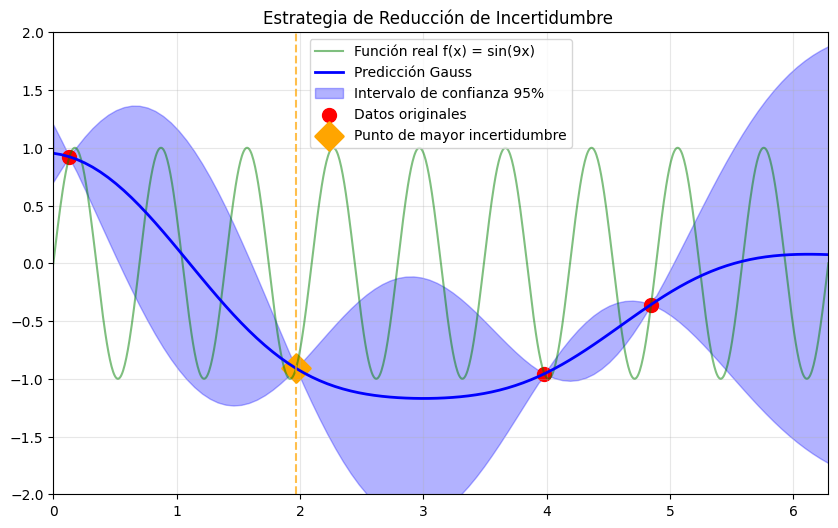

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(X_real, y_real, 'g-', alpha=0.5, label='Función real f(x) = sin(9x)')
plt.plot(X_test, y_pred_unc, 'b-', label='Predicción Gauss', linewidth=2)

# AQUI se grafica el intervalo al 95% = 2 desviaciones estandar
plt.fill_between(X_test.ravel(),
                 y_pred_unc - 2*y_std_unc,
                 y_pred_unc + 2*y_std_unc,
                 alpha=0.3, color='blue', label='Intervalo de confianza 95%')
plt.scatter(X_train, y_train, color='red', s=100, label='Datos originales')
plt.scatter([x_uncertainty], f(x_uncertainty), color='orange', s=200, marker='D', linewidth=2, label=f'Punto de mayor incertidumbre')

plt.axvline(x=x_uncertainty, color='orange', linestyle='--', alpha=0.7)

plt.title(f'Estrategia de Reducción de Incertidumbre ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 2*np.pi)
plt.ylim(-2, 2)
plt.show()

Repitamos el proceso 30 veces con una función distinta.

$$ f(x) = \sin{(\frac{x}{3})} + \cos{(2x)},\ \ \ \ x \in [-5\pi, 5\pi] $$

In [35]:
np.random.seed(42)

# función objetivo
def f_30(x):
    return np.sin(x/3) + np.cos(2*x)

# rango de x
x_min_30, x_max_30 = -5*np.pi, 5*np.pi

# Número de repeticiones
n_repeticiones_30 = 30

# esto es para hacer la base las gráficas de los escenarios
X_plot_30 = np.linspace(x_min_30, x_max_30, 1000)
y_plot_30 = f_30(X_plot_30)

In [38]:
def realizar_iteracion_30(iteracion):
    # Datos iniciales
    X_train_30 = np.random.uniform(x_min_30, x_max_30, 3).reshape([-1, 1])
    y_train_30 = f_30(X_train_30)

    # Entrenamos modelo inicial
    # (random_state=42+iteracion) generar diferentes semillas para cada iteración
    # Si dejara la misma semilla en todas las iteraciones =  cada iteración tedría exactamente los mismos números aleatorios
    # y los resultados serían idénticos en cada iteración
    gpr_30 = Pipeline([('gp', GaussianProcessRegressor(random_state=42+iteracion))])
    gpr_30.fit(X_train_30, y_train_30)

    # predicción
    X_test_30 = np.linspace(x_min_30, x_max_30, 1000).reshape(-1, 1)
    #  return_std=True te arroja la desviación estándar de la predicción = que tan confiable es
    y_pred_30, y_std_30 = gpr_30.predict(X_test_30, return_std=True)

    # Buscar puntos según cada estrategia / escenario
    # AQUI YA ESTAMOS MODIFICANDO EL COMPORTAMIENTO DE SELECCION
    idx_max_30 = np.argmax(y_pred_30)
    x_chosen_max_30 = X_test_30[idx_max_30][0]

    idx_min_30 = np.argmin(y_pred_30)
    x_chosen_min_30 = X_test_30[idx_min_30][0]

    idx_unc_30 = np.argmax(y_std_30)
    x_chosen_unc_30 = X_test_30[idx_unc_30][0]

    # Guardamos resultados para graficar
    # es la etiqueta o el nombre : el valor correspondiente
    resultados_30 = {
        'X_train': X_train_30,
        'y_train': y_train_30,
        'X_test': X_test_30,
        'max': {'x': x_chosen_max_30, 'y_pred': y_pred_30, 'y_std': y_std_30},
        'min': {'x': x_chosen_min_30, 'y_pred': y_pred_30, 'y_std': y_std_30},
        'unc': {'x': x_chosen_unc_30, 'y_pred': y_pred_30, 'y_std': y_std_30}}

    return resultados_30

resultado = realizar_iteracion_30(0)

- Maximizar

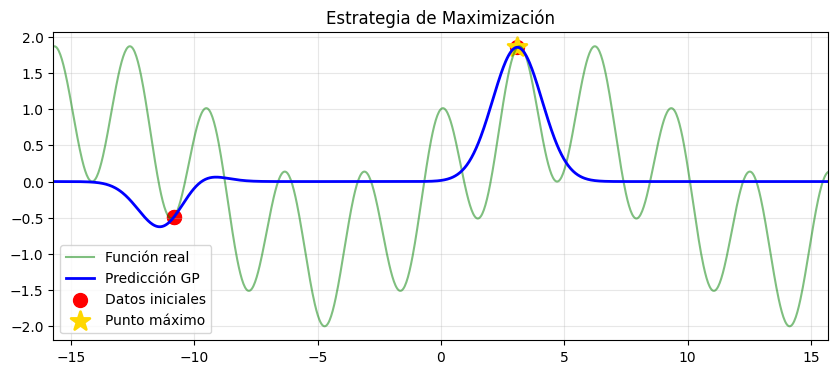

In [41]:
plt.figure(figsize=(10, 4))
plt.plot(X_plot_30, y_plot_30, 'g-', alpha=0.5, label='Función real')
plt.plot(resultado['X_test'], resultado['max']['y_pred'], 'b-', label='Predicción GP', linewidth=2)

plt.scatter(resultado['X_train'], resultado['y_train'], color='red', s=100, label='Datos iniciales')
plt.scatter(resultado['max']['x'], f_30(resultado['max']['x']), color='gold', s=200, marker='*', linewidth=2, label='Punto máximo')

plt.title(f'Estrategia de Maximización')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(x_min_30, x_max_30)
plt.show()

- Minimizar

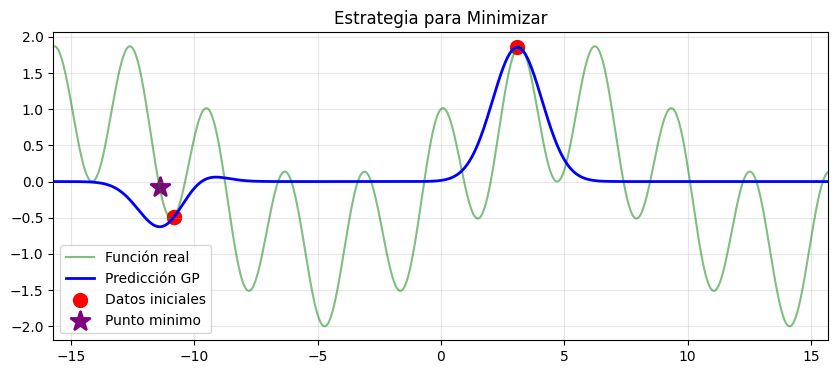

In [43]:
plt.figure(figsize=(10, 4))
plt.plot(X_plot_30, y_plot_30, 'g-', alpha=0.5, label='Función real')
plt.plot(resultado['X_test'], resultado['min']['y_pred'], 'b-', label='Predicción GP', linewidth=2)

plt.scatter(resultado['X_train'], resultado['y_train'], color='red', s=100, label='Datos iniciales')
plt.scatter(resultado['min']['x'], f_30(resultado['min']['x']), color='purple', s=200, marker='*', linewidth=2, label='Punto minimo')

plt.title(f'Estrategia para Minimizar')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(x_min_30, x_max_30)
plt.show()

- Reducción de incertidumbre

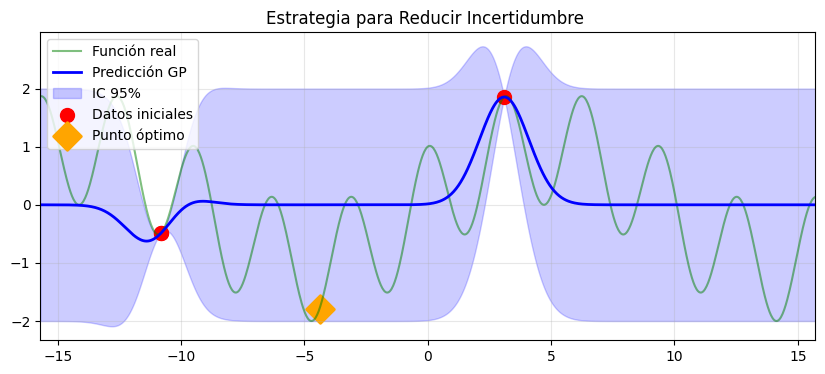

In [44]:
plt.figure(figsize=(10, 4))
plt.plot(X_plot_30, y_plot_30, 'g-', alpha=0.5, label='Función real')
plt.plot(resultado['X_test'], resultado['unc']['y_pred'], 'b-', label='Predicción GP', linewidth=2)

#Intervalo
plt.fill_between(resultado['X_test'].ravel(),
                 resultado['unc']['y_pred'] - 2*resultado['unc']['y_std'],
                 resultado['unc']['y_pred'] + 2*resultado['unc']['y_std'],
                 alpha=0.2, color='blue', label='IC 95%')
plt.scatter(resultado['X_train'], resultado['y_train'], color='red', s=100, label='Datos iniciales')
plt.scatter(resultado['unc']['x'], f_30(resultado['unc']['x']), color='orange', s=200, marker='D', linewidth=2, label='Punto óptimo ')

plt.title(f'Estrategia para Reducir Incertidumbre ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(x_min_30, x_max_30)
plt.show()

### Actividad

1. Modificar el comportamiento de selección para elegir el máximo de las predicciones como el siguiente punto.


In [45]:
# hacemos lo mismo de arriba solo que sin las 30 iteraciones, osea lo dejamos simple con 1
np.random.seed(42)

# función objetivo
def f_act1(x):
    return np.sin(x/3) + np.cos(2*x)

# rango de x
x_min_act1, x_max_act1 = -5*np.pi, 5*np.pi
X_plot_act1 = np.linspace(x_min_act1, x_max_act1, 1000)
y_real_act1 = f_act1(X_plot_act1)

# datos iniciales aleatorios
X_train_act1 = np.random.uniform(x_min_act1, x_max_act1, 3).reshape([-1, 1])
y_train_act1 = f_act1(X_train_act1)

In [46]:
# Entrenamos el modelo
gpr_act1 = Pipeline([('gp', GaussianProcessRegressor(random_state=42))])
gpr_act1.fit(X_train_act1, y_train_act1)

# Predección
y_pred_act1, y_std_act1 = gpr_act1.predict(X_plot_act1.reshape(-1, 1), return_std=True)

# Seleccionamos el MÁXIMO
idx_max_act1 = np.argmax(y_pred_act1)
x_max_act1 = X_plot_act1[idx_max_act1]

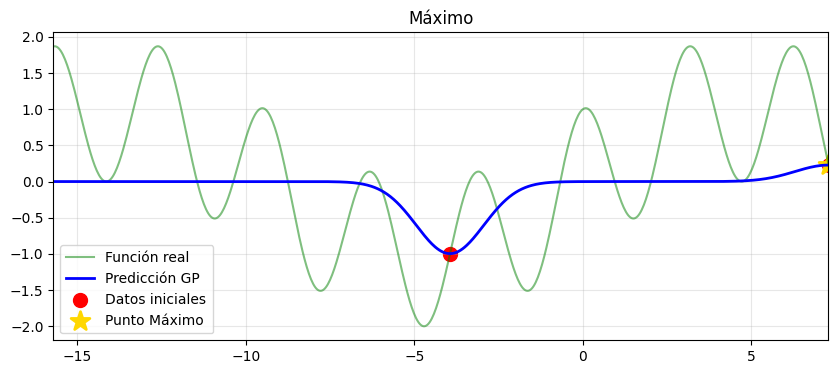

In [51]:
# Graficar
plt.figure(figsize=(10, 4))
plt.plot(X_plot_act1, y_real_act1, 'g-', alpha=0.5, label='Función real')
plt.plot(X_plot_act1, y_pred_act1, 'b-', label='Predicción GP', linewidth=2)

plt.scatter(X_train_act1, y_train_act1, color='red', s=100, label='Datos iniciales')
plt.scatter([x_max_act1], [y_pred_act1[idx_max_act1]], color='gold', s=200, marker='*', linewidth=2, label='Punto Máximo ')

plt.title(f'Máximo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(x_min_act1, x_max_act1)
plt.show()


2. Modificar el comportamiento de selección para elegir el mínimo de las predicciones como el siguiente punto.

In [52]:
np.random.seed(42)

# función objetivo
def f_act1(x):
    return np.sin(x/3) + np.cos(2*x)

# rango de x
x_min_act1, x_max_act1 = -5*np.pi, 5*np.pi
X_plot_act1 = np.linspace(x_min_act1, x_max_act1, 1000)
y_real_act1 = f_act1(X_plot_act1)

# datos iniciales aleatorios
X_train_act1 = np.random.uniform(x_min_act1, x_max_act1, 3).reshape([-1, 1])
y_train_act1 = f_act1(X_train_act1)

In [53]:
# Entrenamos el modelo
gpr_act1 = Pipeline([('gp', GaussianProcessRegressor(random_state=42))])
gpr_act1.fit(X_train_act1, y_train_act1)

# Predección
y_pred_act1, y_std_act1 = gpr_act1.predict(X_plot_act1.reshape(-1, 1), return_std=True)

# Selección del MÍNIMO
idx_min_act1 = np.argmin(y_pred_act1)
x_min_act1 = X_plot_act1[idx_min_act1]

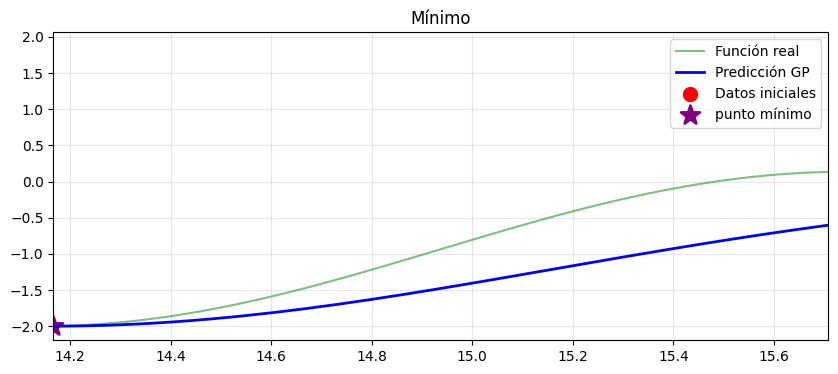

In [54]:
plt.figure(figsize=(10, 4))
plt.plot(X_plot_act1, y_real_act1, 'g-', alpha=0.5, label='Función real')
plt.plot(X_plot_act1, y_pred_act1, 'b-', label='Predicción GP', linewidth=2)

plt.scatter(X_train_act1, y_train_act1, color='red', s=100, label='Datos iniciales')
plt.scatter([x_min_act1], [y_pred_act1[idx_min_act1]], color='purple', s=200, marker='*', linewidth=2, label='punto mínimo ')

plt.title(f'Mínimo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(x_min_act1, x_max_act1)
plt.show()
